# Notebook 01 — The Gradient (∇f)

The gradient turns a **scalar field** into a **vector field**. At every point,
∇f is the vector that points in the direction of fastest increase of f, and
its magnitude is the rate of increase in that direction.

$$\nabla f = \left(\frac{\partial f}{\partial x},\ \frac{\partial f}{\partial y}\right)$$

This notebook walks through one example end-to-end:

1. Derive ∇f by hand.
2. Verify with SymPy.
3. Compute the same thing numerically on a grid with NumPy.
4. Visualize.


In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops
from src import visualizers as viz


## 1. By hand

Let $f(x, y) = x^2 y + \sin(y)$.

Treat the *other* variable as a constant when differentiating:

- $\dfrac{\partial f}{\partial x} = 2xy$  *(y is constant, so $\sin(y)$ vanishes)*
- $\dfrac{\partial f}{\partial y} = x^2 + \cos(y)$

So $\nabla f = (2xy,\ x^2 + \cos(y))$.

**Sanity check at $(1, 0)$:** $\nabla f = (2 \cdot 1 \cdot 0,\ 1 + \cos 0) = (0, 2)$.
The function climbs fastest in the $+y$ direction at that point, with rate 2.


## 2. SymPy verification

In [2]:
x, y = sp.symbols('x y')
f_sym = x**2 * y + sp.sin(y)

grad_sym = [sp.diff(f_sym, v) for v in (x, y)]
print("∂f/∂x =", grad_sym[0])
print("∂f/∂y =", grad_sym[1])

# Evaluate at (1, 0) — should match our by-hand result (0, 2)
print("∇f(1, 0) =", [g.subs({x: 1, y: 0}) for g in grad_sym])


∂f/∂x = 2*x*y
∂f/∂y = x**2 + cos(y)
∇f(1, 0) = [0, 2]


## 3. NumPy on a grid

Now suppose all we have is the *values* of $f$ on a discrete grid (the
situation with any real measured field). We approximate the partials with
**central finite differences**:

$$\frac{\partial f}{\partial x}\bigg|_{i,j} \approx \frac{f_{i,j+1} - f_{i,j-1}}{2\,\Delta x}$$

That's exactly what `np.gradient` does internally.


In [3]:
# Grid
x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_vals, y_vals)
dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]

# Sample f on the grid
f = X**2 * Y + np.sin(Y)

# Numerical gradient
df_dx_num, df_dy_num = ops.gradient_2d(f, dx, dy)

# Analytical gradient (for comparison)
df_dx_exact = 2 * X * Y
df_dy_exact = X**2 + np.cos(Y)

err_x = np.max(np.abs(df_dx_num - df_dx_exact))
err_y = np.max(np.abs(df_dy_num - df_dy_exact))
print(f"Max |numerical − exact| in ∂f/∂x: {err_x:.2e}")
print(f"Max |numerical − exact| in ∂f/∂y: {err_y:.2e}")


Max |numerical − exact| in ∂f/∂x: 4.02e-02
Max |numerical − exact| in ∂f/∂y: 9.17e-03


The error is small (≈ grid-spacing²) because central differences are
second-order accurate. The error concentrates at the grid boundary, where
NumPy falls back to one-sided differences.

## 4. Visualization

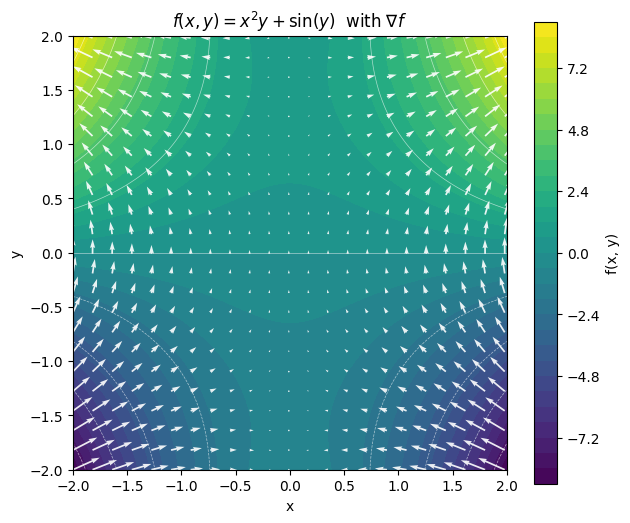

In [4]:
fig = viz.plot_scalar_with_gradient(
    X, Y, f, df_dx_num, df_dy_num,
    title=r"$f(x,y) = x^2 y + \sin(y)$  with $\nabla f$",
    n_arrows=22,
)
plt.show()


**How to read this plot.** The colored contours are level sets of $f$ —
points of equal value. The white arrows are $\nabla f$. Two things to notice:

1. **Arrows are perpendicular to contours.** This is a theorem, not a
   coincidence: along a contour $f$ is constant, so the rate of change in that
   direction is zero, so the gradient (which captures *all* directional
   derivatives) must be perpendicular to it.
2. **Arrows are longer where contours are bunched up.** Closely-spaced
   contours mean $f$ is changing rapidly, which is exactly what $|\nabla f|$
   measures.


## 5. Exercise

Try this by hand, then verify:

$$g(x, y) = e^{-x^2 - y^2}\cos(x)$$

Compute $\nabla g$ analytically and at the point $(0, 0)$. What direction does
the gradient point at $(1, 0)$? Does that make sense given the shape of $g$?

(Hints: at $(0,0)$ both partials should equal zero — that's a critical point.
At $(1, 0)$ the field is strongly decaying, so expect the gradient to point
back toward the origin.)


In [5]:
# Your answer here.
# x, y = sp.symbols('x y')
# g_sym = sp.exp(-x**2 - y**2) * sp.cos(x)
# ...
